In [2]:
import numpy as np
import pandas as pd 
data=pd.read_csv("student_eda_practice.csv")
data_2=data.copy()
data_2.isnull().sum()

student_id               0
age                      4
city                     3
course                   0
gender                   0
study_hours              5
attendance               4
assignments_completed    0
exam_score               4
monthly_expense          3
signup_date              0
lead_source              0
dtype: int64

In [3]:
data_2.head()

,student_id,age,city,course,gender,study_hours,attendance,assignments_completed,exam_score,monthly_expense,signup_date,lead_source
0,1001,23.0,Pune,Electronics,Male,8.5,96.1,7,46.2,14649.0,2025-01-01,Instagram
1,1002,20.0,Surat,Mechanical,Male,1.3,81.3,4,56.9,4298.0,2025-01-04,Google
2,1003,24.0,Jaipur,Computer Science,Female,4.3,87.7,15,54.4,12537.0,2025-01-07,Referral
3,1004,21.0,Mumbai,Computer Science,Male,8.7,89.1,10,69.6,12100.0,2025-01-10,Google
4,1005,23.0,Delhi,Mechanical,Male,5.4,72.0,3,NaN,7791.0,2025-01-13,Referral


In [4]:
# Do fill the null values with the help of machine learning
from sklearn.impute import SimpleImputer
data_2_numbers=data_2.drop(['city','course','gender','signup_date','lead_source'],axis=1)
data_2_string=data_2[['city','course','gender','signup_date','lead_source']]
data_2_numbers

impute=SimpleImputer(strategy='mean')
data_2_mean_value=impute.fit_transform(data_2_numbers)
data_2_dataframe=pd.DataFrame(data_2_mean_value,columns=data_2_numbers.columns,index=data_2.index)
data_2_dataframe

,student_id,age,study_hours,attendance,assignments_completed,exam_score,monthly_expense
0,1001.0,23.0,8.5,96.1,7.0,46.20000,14649.0
1,1002.0,20.0,1.3,81.3,4.0,56.90000,4298.0
2,1003.0,24.0,4.3,87.7,15.0,54.40000,12537.0
3,1004.0,21.0,8.7,89.1,10.0,69.60000,12100.0
4,1005.0,23.0,5.4,72.0,3.0,48.55411,7791.0
...,...,...,...,...,...,...,...
145,1146.0,25.0,1.1,80.9,8.0,51.10000,12560.0
146,1147.0,20.0,1.6,96.3,2.0,46.20000,13026.0
147,1148.0,17.0,6.5,55.2,15.0,20.20000,5874.0
148,1149.0,17.0,5.3,98.9,5.0,44.10000,11708.0


In [5]:
#After working on the number , we will work on the string value at the place of null 
data_2_string=data_2_string.fillna("No value")
data_2_string
#Now we will concat here 
data_2_new=pd.concat([data_2_dataframe,data_2_string],axis=1)
data_2_new
# Work on the queries for pandas
query_1=data_2_new.query("attendance>90")
query_1
new_data=data_2_dataframe.astype(int)
new_data

,student_id,age,study_hours,attendance,assignments_completed,exam_score,monthly_expense
0,1001,23,8,96,7,46,14649
1,1002,20,1,81,4,56,4298
2,1003,24,4,87,15,54,12537
3,1004,21,8,89,10,69,12100
4,1005,23,5,72,3,48,7791
...,...,...,...,...,...,...,...
145,1146,25,1,80,8,51,12560
146,1147,20,1,96,2,46,13026
147,1148,17,6,55,15,20,5874
148,1149,17,5,98,5,44,11708


In [11]:
# Now we will see duplicates value
data_copy=data_2_new.copy()
data_copy.columns.duplicated()

#Average value with the help of pandas as well . Pandas is crucial same as ML 
data_copy.head()
data_avg_age=data_copy['age'].mean()
round(data_avg_age,1) # Just like SQL here we have round 
data_avg_hours=data_copy['study_hours'].mean()
round(data_avg_hours,1)

dataframing=pd.concat([new_data,data_2_string],axis=1)
dataframing.isnull().sum()
dataframing.query("study_hours>6 and exam_score>70")
# sorte=dataframing.sort_values(ascending=False)
dataframing

grouping=dataframing.groupby("course")['exam_score'].mean()
grouping
#Group by function and average value

course
Computer Science    48.400000
Data Science        50.564103
Electronics         45.606061
Mechanical          47.511628
Name: exam_score, dtype: float64

In [14]:
dataframing.head()

,student_id,age,study_hours,attendance,assignments_completed,exam_score,monthly_expense,city,course,gender,signup_date,lead_source
0,1001,23,8,96,7,46,14649,Pune,Electronics,Male,2025-01-01,Instagram
1,1002,20,1,81,4,56,4298,Surat,Mechanical,Male,2025-01-04,Google
2,1003,24,4,87,15,54,12537,Jaipur,Computer Science,Female,2025-01-07,Referral
3,1004,21,8,89,10,69,12100,Mumbai,Computer Science,Male,2025-01-10,Google
4,1005,23,5,72,3,48,7791,Delhi,Mechanical,Male,2025-01-13,Referral


In [27]:
avg_hours=dataframing.groupby("course")['exam_score'].mean()
gendering=dataframing[['gender']]
rounded=round(avg_hours,1)
frame_new=rounded.to_frame()
frame_new
# fram_new=pd.DataFrame(rounded,columns=rounded.columns,index=rounded.index)
# frame_new

,exam_score
course,
Computer Science,48.4
Data Science,50.6
Electronics,45.6
Mechanical,47.5


In [31]:
short_dataframing=dataframing.head()

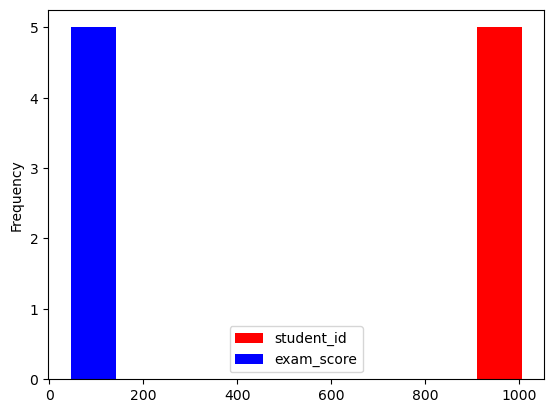

In [34]:
#Plot the histogram here
import matplotlib.pyplot as plt 
short_dataframing[['student_id', 'exam_score']].plot(
    kind='hist',
    color=['Red','Blue']
)

plt.show()
plt.show()


In [38]:
# Total no of students in each course - Do grouping
no_of_students=short_dataframing.groupby('course')['student_id'].sum()
dataframe_students=no_of_students.to_frame()
dataframe_students
dataframe_students.plot(kind='bar',x='course',y='student_id',color='Red')
plt.show()

,student_id
course,
Computer Science,2007
Electronics,1001
Mechanical,2007


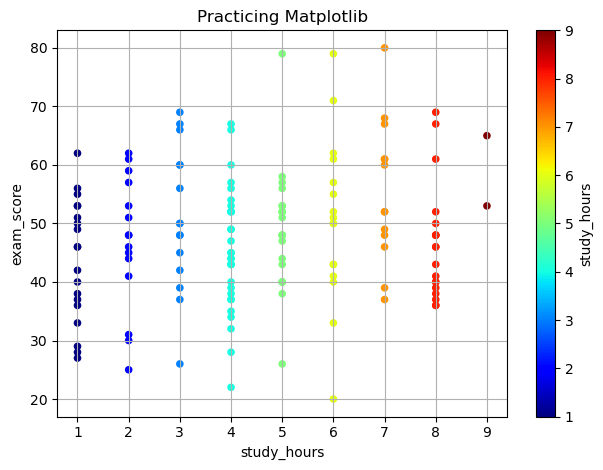

In [43]:
# Create a scatterplot between study hours and exam score here
dataframing.plot(kind='scatter',x='study_hours',y='exam_score',cmap='jet',c='study_hours')
plt.title("Practicing Matplotlib")
plt.grid(True)
plt.style.use("ggplot")
plt.tight_layout()
plt.show()


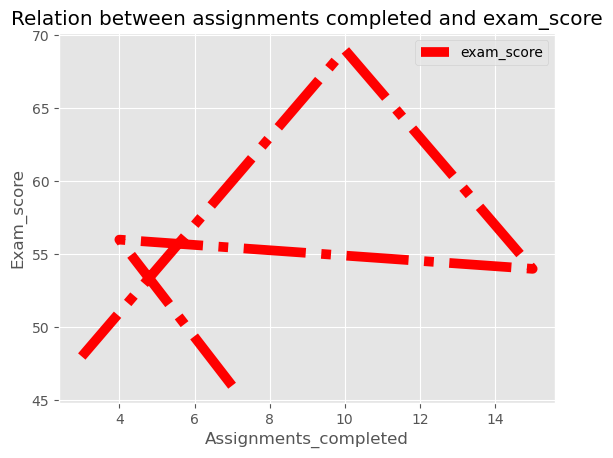

In [57]:
dataframing.isnull().sum()
dataframing
# Q1 . Which city has the highest average exam score?
avg_exam_score=dataframing.groupby("city")['exam_score'].mean()
avg_exam_score
dataframe_avg_exam_score=avg_exam_score.to_frame()
dataframe_avg_exam_score.sort_values(by="exam_score",ascending=False)
#I find interesting that by is used for telling which column and to_frame creates to dataframe directly WOWWWWWWW


# Q2 . Which course has the highest average study hours?

avg_hours=dataframing.groupby("course")['study_hours'].mean()
avg_hours
dataframe_avg_hours=round(avg_hours,1).to_frame()
dataframe_avg_hours.sort_values(by='study_hours',ascending=False)


# Q.3 Relation between assignments completed and exam_score
short_dataframing.plot(kind='line',x='assignments_completed',y='exam_score',linewidth=7,linestyle="-.",color='Red')
plt.title("Relation between assignments completed and exam_score")
plt.xlabel('Assignments_completed')
plt.ylabel('Exam_score')
plt.show()

# It is always recommended to not overwrite the original dataframe , create a copy and use that only.